在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd
# 加载数据
# data = pd.read_csv('../my/hh_result/result_all.csv', dtype={'flt_no': str})
# data_24 = pd.read_csv('../my/hh_result/result_24_7-10.csv', dtype={'flt_no': str})
data = pd.read_csv('../../my/hh_result/result_23_6-pax>20.csv', dtype={'flt_no': str})
data_24 = pd.read_csv('../../my/hh_result/result_24_7-10-pax>20.csv', dtype={'flt_no': str})

# 合并数据
data = pd.concat([data, data_24], ignore_index=True)

# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7725744 entries, 0 to 7725743
Data columns (total 21 columns):
 #   Column      Dtype  
---  ------      -----  
 0   flt_no      object 
 1   a           object 
 2   b           object 
 3   c           object 
 4   bd_type     object 
 5   cap         float64
 6   aircraft    object 
 7   legs        int64  
 8   leg_no      int64  
 9   duration    float64
 10  pax         int64  
 11  year        int64  
 12  month       int64  
 13  day         int64  
 14  weekday     int64  
 15  hour        int64  
 16  minute      int64  
 17  second      int64  
 18  from        object 
 19  to          object 
 20  unit_price  float64
dtypes: float64(3), int64(10), object(8)
memory usage: 1.2+ GB
None


In [2]:
# 获取第0列的列名
first_column_name = data.columns[0]
print("第0列的列名:", first_column_name)

# 查看第0列的唯一值类型
unique_types = data.iloc[:, 0].apply(type).unique()
print("\n第0列中的数据类型：")
print(unique_types)

# 查看第0列的唯一值
unique_values = data.iloc[:, 0].unique()
print("\n第0列中的唯一值示例：")
print(unique_values[:10])  # 显示前10个唯一值

# 统计每种类型的数量
type_counts = data.iloc[:, 0].apply(type).value_counts()
print("\n每种类型的数量：")
print(type_counts)

第0列的列名: flt_no

第0列中的数据类型：
[<class 'str'>]

第0列中的唯一值示例：
['3017' '3018' '3051' '3052' '3053' '3054' '3055' '3056' '3173' '3174']

每种类型的数量：
flt_no
<class 'str'>    7725744
Name: count, dtype: int64


In [3]:
# 使用apply和isinstance筛选出类型为int的行
int_rows = data[data['flt_no'].apply(lambda x: isinstance(x, int))]

# 显示结果
print("数据类型为int的行数:", len(int_rows))
print("\n前10行数据示例：")
print(int_rows.head(10))

# 查看这些int类型的值的分布情况
print("\nint类型的唯一值：")
print(int_rows['flt_no'].unique())

数据类型为int的行数: 0

前10行数据示例：
Empty DataFrame
Columns: [flt_no, a, b, c, bd_type, cap, aircraft, legs, leg_no, duration, pax, year, month, day, weekday, hour, minute, second, from, to, unit_price]
Index: []

[0 rows x 21 columns]

int类型的唯一值：
[]


### 统计不同城市的频率

In [4]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

    city   count
0    CAN  632091
1    SZX  590292
2    TFU  568829
3    PKX  526603
4    KMG  522955
..   ...     ...
249  HPG     205
250  HBQ     121
251  DDR     118
252  XNT      90
253  HZH      49

[254 rows x 2 columns]


In [5]:
import json

# 保存 city_map 到 JSON 文件
with open('../../my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


### 'flt_no', 'bd_type', 'aircraft'编码

In [6]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../my/encoder/aircraft_encoder_all.pkl


## 生成加权图

In [7]:
# 创建一个新的数据框，用于存储航班频数
flight_counts = data.groupby(['from', 'to']).size().reset_index(name='flight_count')

# 打印查看
print(flight_counts.shape)
print(flight_counts.head())


(8299, 3)
  from   to  flight_count
0  AAT  AKU           223
1  AAT  BPL           126
2  AAT  CAN            82
3  AAT  CGO           101
4  AAT  CGQ            32


In [8]:
import networkx as nx

# 创建一个空图
G = nx.Graph()

# 将城市作为节点，航班频数作为边的权重添加到图中
for index, row in flight_counts.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['flight_count'])

# 输出图的基本信息
print("图的节点数:", G.number_of_nodes())
print("图的边数:", G.number_of_edges())

图的节点数: 254
图的边数: 4204


/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29677 (\N{CJK UNIFIED IDEOGRAPH-73ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/data/envs/machine/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDE

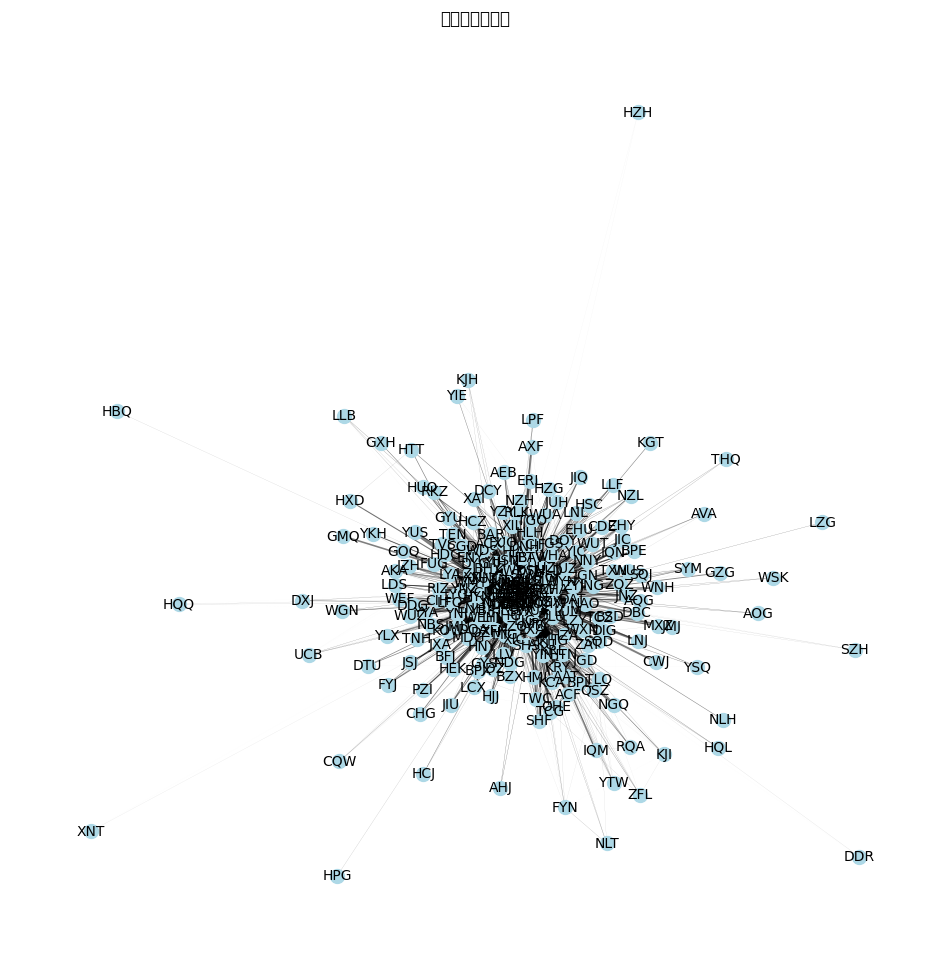

In [9]:
import matplotlib.pyplot as plt

# 设置图的布局
plt.figure(figsize=(12, 12))

# 绘制加权图，边的宽度表示航班频数
pos = nx.spring_layout(G, k=0.5)  # 使用 spring 布局来可视化图
edges = G.edges(data=True)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# 绘制边，边的宽度表示航班频数（weight）
nx.draw_networkx_edges(G, pos, width=[d['weight'] / 1000 for u, v, d in edges], alpha=0.5)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10)

# 显示图形
plt.title("加权航班网络图")
plt.axis('off')
plt.show()

## 创建并训练 DeepWalk 模型

In [10]:
import numpy
print(numpy.__version__)

1.24.4


In [11]:
import networkx as nx
from node2vec import Node2Vec

/opt/data/envs/machine/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. 加载图并准备数据

In [12]:
node2vec = Node2Vec(G, 
                   dimensions=64, 
                   walk_length=3, 
                   num_walks=2000, 
                   workers=4,
                   weight_key='weight')

model = node2vec.fit(window=3, 
                    min_count=1, 
                    batch_words=4)

Generating walks (CPU: 4): 100%|██████████| 500/500 [00:04<00:00, 121.49it/s]


2. 获取节点的嵌入向量

In [13]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.719312   -0.57018155  0.04421988 -0.44650933 -0.05957176 -0.6233309
 -0.20042339  0.02729189 -0.05519923  0.09146199  0.33637366 -0.08693642
  0.27942097 -0.2881204   0.7492074   0.21601269  0.09450664 -0.2128355
 -0.26566344  0.44615176  0.12384446  0.27500516  0.7510423  -0.28918067
  0.2725454   0.46062046  0.10949916 -0.25948417  0.26218885 -0.65573275
 -0.38648608 -0.10895362  0.20945354  0.36406943 -0.5530245  -0.39981946
  0.1276666   0.3966809   0.4384379   0.39563882  0.42042452 -0.236617
 -0.40519458  0.136869    0.25339362  0.07446623  0.06257232 -0.504672
 -0.06611901  0.12821735 -0.4764756  -0.12851915  0.0669169   0.43078598
  0.44998944  0.19907314 -0.38574907 -0.835394   -0.08005165  0.39467737
 -0.03933163  0.41410533 -0.34013498  0.05412548]


city_embeddings是一个字典

## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [14]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: AAT, 聚类标签: 2
城市: AKU, 聚类标签: 2
城市: BPL, 聚类标签: 2
城市: CAN, 聚类标签: 1
城市: CGO, 聚类标签: 1
城市: CGQ, 聚类标签: 1
城市: CKG, 聚类标签: 1
城市: HGH, 聚类标签: 1
城市: HRB, 聚类标签: 1
城市: INC, 聚类标签: 1
城市: KCA, 聚类标签: 2
城市: KHG, 聚类标签: 2
城市: KJI, 聚类标签: 2
城市: KRL, 聚类标签: 2
城市: KRY, 聚类标签: 2
城市: LHW, 聚类标签: 1
城市: PKX, 聚类标签: 1
城市: PVG, 聚类标签: 1
城市: SHF, 聚类标签: 2
城市: SZX, 聚类标签: 1
城市: TCG, 聚类标签: 2
城市: TFU, 聚类标签: 1
城市: TLQ, 聚类标签: 2
城市: URC, 聚类标签: 2
城市: WUH, 聚类标签: 1
城市: XIY, 聚类标签: 1
城市: YIN, 聚类标签: 2
城市: ACF, 聚类标签: 2
城市: CSX, 聚类标签: 1
城市: HTN, 聚类标签: 2
城市: RQA, 聚类标签: 2
城市: TWC, 聚类标签: 2
城市: YTW, 聚类标签: 2
城市: ACX, 聚类标签: 1
城市: BAV, 聚类标签: 0
城市: BFJ, 聚类标签: 1
城市: CTU, 聚类标签: 1
城市: FOC, 聚类标签: 1
城市: FUO, 聚类标签: 1
城市: HAK, 聚类标签: 1
城市: HUZ, 聚类标签: 1
城市: JHG, 聚类标签: 1
城市: JJN, 聚类标签: 1
城市: JUZ, 聚类标签: 1
城市: KHN, 聚类标签: 1
城市: KJH, 聚类标签: 1
城市: KMG, 聚类标签: 1
城市: KOW, 聚类标签: 1
城市: KWE, 聚类标签: 1
城市: LLB, 聚类标签: 1
城市: NGB, 聚类标签: 1
城市: NKG, 聚类标签: 1
城市: NNG, 聚类标签: 1
城市: SHS, 聚类标签: 1
城市: SWA, 聚类标签: 1
城市: TEN, 聚类标签: 1
城市: WHA, 聚类标签: 1
城市: WMT, 聚类标签: 1
城市: WNZ, 聚类标签:

### 保存聚类标签

In [15]:
# 首先导入 json 模块
import json
print(city_labels)

# 将字典中的所有值转换为 Python 的原生 int 类型
city_labels = {key: int(value) for key, value in city_labels.items()}

# 保存字典到 JSON 文件
with open('../my/encoder/city_labels_航班频率加权图标签.json', 'w') as file:
    json.dump(city_labels, file)

print("字典已保存为 city_labels.json")

{'AAT': 2, 'AKU': 2, 'BPL': 2, 'CAN': 1, 'CGO': 1, 'CGQ': 1, 'CKG': 1, 'HGH': 1, 'HRB': 1, 'INC': 1, 'KCA': 2, 'KHG': 2, 'KJI': 2, 'KRL': 2, 'KRY': 2, 'LHW': 1, 'PKX': 1, 'PVG': 1, 'SHF': 2, 'SZX': 1, 'TCG': 2, 'TFU': 1, 'TLQ': 2, 'URC': 2, 'WUH': 1, 'XIY': 1, 'YIN': 2, 'ACF': 2, 'CSX': 1, 'HTN': 2, 'RQA': 2, 'TWC': 2, 'YTW': 2, 'ACX': 1, 'BAV': 0, 'BFJ': 1, 'CTU': 1, 'FOC': 1, 'FUO': 1, 'HAK': 1, 'HUZ': 1, 'JHG': 1, 'JJN': 1, 'JUZ': 1, 'KHN': 1, 'KJH': 1, 'KMG': 1, 'KOW': 1, 'KWE': 1, 'LLB': 1, 'NGB': 1, 'NKG': 1, 'NNG': 1, 'SHS': 1, 'SWA': 1, 'TEN': 1, 'WHA': 1, 'WMT': 1, 'WNZ': 1, 'ZUH': 1, 'ZYI': 1, 'AEB': 1, 'AHJ': 1, 'LXA': 1, 'AKA': 1, 'TSN': 1, 'FYN': 2, 'HMI': 2, 'HXD': 2, 'PEK': 1, 'QSZ': 2, 'TAO': 1, 'XNN': 1, 'ZFL': 2, 'AOG': 1, 'AQG': 1, 'AVA': 1, 'LJG': 1, 'AXF': 0, 'DSN': 1, 'HET': 0, 'HLD': 0, 'BAR': 1, 'HFE': 1, 'JGS': 1, 'JMJ': 1, 'SHA': 1, 'SHE': 1, 'SJW': 1, 'TYN': 1, 'YBP': 1, 'CIF': 0, 'DLC': 1, 'ERL': 0, 'HDG': 1, 'HLH': 0, 'LFQ': 1, 'NZH': 0, 'TGO': 0, 'TNA': 1,

FileNotFoundError: [Errno 2] No such file or directory: '../my/encoder/city_labels_航班频率加权图标签.json'

## 二维空间聚类效果展示

步骤 4：可视化嵌入

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

## 保存嵌入表示

In [ ]:
import numpy as np
import json

# 获取城市列表
cities = list(city_embeddings.keys())

# 将降维后的嵌入表示转换为列表格式
reduced_embeddings_list = reduced_embeddings.tolist()

# 保存城市和其对应的嵌入（将 NumPy 数组转换为列表）
city_embedding_dict = {city: reduced_embeddings[i].tolist() for i, city in enumerate(cities)}

# 将 city_embedding_dict 保存为 JSON 文件
with open('../my/encoder/城市嵌入编码_航班频率加权图.json', 'w') as f:
    json.dump(city_embedding_dict, f)

print("城市嵌入表示已保存。")

In [ ]:
city_embedding_dict